In [34]:
# 01.09.2026 - Watek 4 z planu 20260831/20260831_plan.md: TEST MEDIANY
# LOKALNEJ, czyli sprawdzenie najbardziej prawdopodobnego alternatywnego
# wyjasnienia calego ~10-letniego rytmu minimow. Kierunek wskazany wprost
# przez Homole (komentarz [o]: "Ze wzgledu na te dlugofalowe trendy warto
# popróbowac z medianami lokalnymi, sam probuje w tym kierunku").
#
# HIPOTEZA DO SPRAWDZENIA. cosmoseismic_stat normalizuje |dnCR| oraz Sm
# mediana liczona na CALYM oknie 3350 dni. Okno ma ~9,2 roku, a szereg CR ma
# silny cykl ~11-letni - wiec znak B = |dnCR|/mediana - 1 (i tak samo A dla
# trzesien) moze systematycznie zalezec od tego, w ktora faze cyklu
# slonecznego trafilo okno. Samo w sobie wygenerowaloby to okresowosc
# minimow zgodna z cyklem ORAZ zgodnosc miedzy stacjami (bo wszystkie widza
# ten sam cykl). Jesli tak jest, "efekt" jest artefaktem normalizacji.
#
# ZRODLO PROSBY - doslowny cytat, zeby nie realizowac wlasnej interpretacji
# zamiast tego, o co proszono (zrodla/Maciej Flaga Praktyki 2026.txt, komentarz
# [PH] z 24.07, wiersz 284):
#   "proponowalbym poprobowanie dla wybranej stacji z lokalnymi medianami,
#    tzn. z oknami o dlugosciach rzedu 50-100 dni, ew. dla median biegnacych,
#    tzn. dla kazdej pary przedzialow okreslamy znak + lub - wg wartosci
#    mediany z obszaru i +/- n binow, np. n = 40"
# Homola opisuje tu DWA rozne warianty: (i) krotkie okna analizy 50-100 dni,
# (ii) mediane biegnaca liczona z obszaru +-n binow wokol kazdego binu, n=40.
# TEN notebook realizuje wariant (ii). Wariant (i) to zmiana szerokosci calego
# okna analizy P (z 3350 na 50-100 dni), czyli inny, znacznie wiekszy watek -
# nie jest tu robiony i nie wolno go mylic z (ii).
#
# PRZELICZENIE n NA DNI (pierwsza wersja tego notebooka miala tu blad,
# 01.09.2026, wylapany przez Macka): n jest podane W BINACH, nie w dniach.
#   n = 40  ->  polowa szerokosci 40 binow = 40 * 5 = 200 dni
#           ->  cale okno 40 + 1 + 40 = 81 binow = 405 dni
# Bledna pierwsza wersja liczyla "401 binow = 2005 dni", czyli n = 200 - okno
# 5x za szerokie. Dlatego OD TEJ WERSJI warianty sa parametryzowane WPROST W
# BINACH (polowa szerokosci), tak jak mowi o tym Homola, a przeliczenie na dni
# robi juz tylko wydruk. Zamiana jednostek nie ma sie gdzie schowac.
#
# METODA. NIE przeliczamy calego skanu. Bierzemy konkretne punkty t0 i liczymy
# w nich statystyke w kilku wariantach normalizacji:
#   (1) mediana calego okna 3350 dni (przepis artykulu, wariant odniesienia),
#   (2) mediana biegnaca +-40 binow = 2005 dni (doslownie recepta Homoli),
#   (3) mediana biegnaca 365 i 1095 dni (test wrazliwosci na dlugosc okna),
#   (4) mediana biegnaca zastosowana TYLKO po stronie trzesien albo TYLKO po
#       stronie CR - to rozstrzyga, po ktorej stronie siedzi ewentualny trend.
#       Punkt (4) jest wazny wlasnie po Watku 3 (20260901a.ipynb): skladnik A
#       jest wspolny dla wszystkich 20 stacji z definicji, wiec artefakt po
#       stronie sejsmicznej bylby artefaktem calej sieci naraz.
# Punkty: (a) ~55 minimow znalezionych 31.08 (Watek 1, wszystkie stacje x
# ery), (b) LOSOWE punkty kontrolne poza erami - bez nich test jest bez
# sensu, bo jesli mediana lokalna oslabia statystyke WSZEDZIE tak samo, to
# spadek w minimach niczego nie dowodzi. Interesuje nas KONTRAST minima vs
# tlo, osobno w kazdym wariancie.
#
# WAZNE - to jest ODSTEPSTWO od przepisu artykulu i raportujemy je wylacznie
# jako test odpornosci, nigdy jako "poprawiona" wersje replikacji.
#
# KOSZT: ~855 okien x 1 binowanie (trzy warianty mediany licza sie na tym
# samym binowaniu) - rzedu kilku minut. Najwolniejszy jest sam odczyt danych
# CR, w szczegolnosci Oulu (plik 5-minutowy, 151 MB, resample do 6h).
import json
import os
import sys

import numpy as np
import pandas as pd
from scipy.stats import binom, norm

RESULTS_DIR = "../results"
DATA_DIR = "../data"

MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"
OULU_PATH = f"{DATA_DIR}/oulu_5min_data.csv"
EXTENDED_DIR = f"{DATA_DIR}/csv_data_stations_extended"
FULL6H_DIR = f"{DATA_DIR}/csv_data_stations_full6h"
USGS_EXTENDED_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"

P_DAYS = 3350
D_DAYS = 5
M_THRESHOLD = 4.0
DT_DAYS = 15
# Warianty normalizacji: (nazwa, n dla A = trzesienia, n dla B = CR), gdzie n to
# POLOWA SZEROKOSCI okna mediany biegnacej W BINACH (cale okno = 2n+1 binow).
# None = mediana calego okna 3350 dni, czyli przepis artykulu.
# n = 40 to doslownie recepta Homoli. Reszta drabiny sluzy sprawdzeniu, przy
# jakiej szerokosci okna efekt ginie - czyli na jakiej skali czasowej zyje.
WARIANTY = [
    ("artykul", None, None),
    ("homola_n40", 40, 40),
    ("waska_n20", 20, 20),
    ("szeroka_n100", 100, 100),
    ("szeroka_n200", 200, 200),
    ("tylko_EQ_n40", 40, None),
    ("tylko_CR_n40", None, 40),
]
WARIANT_GLOWNY = "homola_n40"  # recepta Homoli - do wykresow porownawczych


# Loadery i cosmoseismic_stat przepisane 1:1 z 20260826/20260826d.ipynb,
# komorka 0 (konwencja repo: notebooki sa samodzielne). Nie modyfikowac -
# to jest wersja, ktora 24.08 odtworzyla wynik artykulu dla Moskwy.
def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_oulu():
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"].resample("6h").mean()


def load_station(station):
    ext_path = os.path.join(EXTENDED_DIR, f"{station.lower()}_extended_6h.csv")
    full_path = os.path.join(FULL6H_DIR, f"{station.lower()}_full_6h.csv")
    path = ext_path if os.path.exists(ext_path) else full_path
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_cr(station):
    if station == "mosc":
        return load_mosc()
    if station == "oulu":
        return load_oulu()
    return load_station(station)


def load_earthquakes_extended(min_mag=M_THRESHOLD):
    df = pd.read_csv(USGS_EXTENDED_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR = nCR_i - nCR_im1
    Sm = sm_vals[1:]

    med_Sm = np.nanmedian(Sm)
    med_dCR = np.nanmedian(np.abs(dCR))

    A = Sm / med_Sm - 1
    B = np.abs(dCR) / med_dCR - 1

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm

    if n_total == 0:
        return dict(N=N, N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    sigma = norm.isf(pcdf)

    return dict(N=N, N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf, sigma=sigma)


eq = load_earthquakes_extended(M_THRESHOLD)
print(f"EQ (rozszerzony katalog, M>={M_THRESHOLD}): {len(eq)} zdarzen, "
      f"{eq.index.min()} .. {eq.index.max()}")


EQ (rozszerzony katalog, M>=4.0): 507919 zdarzen, 1965-01-01 08:04:17.780000 .. 2025-01-31 23:57:39.481000


In [35]:
# Rozdzielenie oryginalnej funkcji na dwa kroki, zeby trzy warianty
# mediany liczyly sie na TYM SAMYM binowaniu (trzykrotna oszczednosc czasu
# i gwarancja, ze porownujemy wariant do wariantu, a nie do innego zestawu
# binow):
#   binuj_okno()     - wszystko az do binow wlacznie (identycznie jak wyzej),
#   statystyka_z_binow() - reszta rachunku, z parametrem okna mediany.
# Rownowaznosc obu drog dla wariantu None jest sprawdzana w nastepnej
# komorce (kontrola do zapisanych wynikow skanu z 26.08).
def binuj_okno(cr, eq, t0, P_days=P_DAYS, d_days=D_DAYS, dt_days=DT_DAYS):
    N = int(P_days // d_days)
    edges = pd.date_range(t0, periods=N + 1, freq=pd.Timedelta(days=d_days))
    eq_edges = edges + pd.Timedelta(days=dt_days)

    cr_cats = pd.cut(cr.index, edges, right=False)
    cr_binned = cr.groupby(cr_cats, observed=False).mean().reindex(cr_cats.categories)
    cr_vals = cr_binned.to_numpy()

    eq_in_range = eq[(eq.index >= eq_edges[0]) & (eq.index < eq_edges[-1])]
    eq_cats = pd.cut(eq_in_range.index, eq_edges, right=False)
    eq_binned = eq_in_range.groupby(eq_cats, observed=False).sum().reindex(eq_cats.categories, fill_value=0.0)
    sm_vals = eq_binned.to_numpy()

    return dict(N=N, nCR_i=cr_vals[1:], nCR_im1=cr_vals[:-1], Sm=sm_vals[1:])


def mediana_odniesienia(x, n_binow):
    # n_binow = None -> jedna mediana z calego okna 3350 dni (przepis artykulu)
    # n_binow = liczba -> mediana biegnaca z obszaru "bin i oraz +-n binow",
    #   czyli okno 2n+1 binow wysrodkowane na binie. To jest doslownie zapis z
    #   komentarza Homoli; przeliczenie na dni (n binow = n*5 dni) sluzy tylko
    #   do opisu i nigdzie nie wchodzi do rachunku.
    if n_binow is None:
        return np.nanmedian(x)
    win = 2 * int(n_binow) + 1
    mp = max(5, win // 3)
    return pd.Series(x).rolling(win, center=True, min_periods=mp).median().to_numpy()


def skladniki_A_B(bins, n_binow_A=None, n_binow_B=None):
    nCR_i, nCR_im1, Sm = bins["nCR_i"], bins["nCR_im1"], bins["Sm"]
    abs_dCR = np.abs(nCR_i - nCR_im1)

    med_Sm = mediana_odniesienia(Sm, n_binow_A)
    med_dCR = mediana_odniesienia(abs_dCR, n_binow_B)

    with np.errstate(divide="ignore", invalid="ignore"):
        A = Sm / med_Sm - 1
        B = abs_dCR / med_dCR - 1
    return A, B


def liczba_zmian_znaku(x):
    # ile razy ciag znakow zmienia znak. Dla ciagu losowego ~ (n-1)/2; wartosc
    # duzo mniejsza oznacza, ze znak jest sterowany powolnym TRENDEM (kilka
    # dlugich blokow), a nie fluktuacja z binu na bin. To jest wlasciwa
    # diagnostyka hipotezy o artefakcie normalizacji.
    s = np.sign(x)
    return int((np.diff(s) != 0).sum())


def statystyka_z_binow(bins, n_binow_A=None, n_binow_B=None):
    nCR_i, nCR_im1, Sm = bins["nCR_i"], bins["nCR_im1"], bins["Sm"]
    A, B = skladniki_A_B(bins, n_binow_A, n_binow_B)

    valid = (
        (A != 0) & (B != 0) &
        (nCR_i > 0) & (nCR_im1 > 0) &
        (Sm > 0) &
        ~np.isnan(A) & ~np.isnan(B)
    )
    if not (n_binow_A is None and n_binow_B is None):
        # przy medianie biegnacej mediana moze wyjsc 0 (dziura w danych) i dac
        # nieskonczonosc; w wariancie artykulu ten warunek nic nie zmienia,
        # wiec dokladany jest tylko tutaj, zeby wariant artykulu zostal
        # bit-w-bit taki sam jak oryginalna cosmoseismic_stat
        valid = valid & np.isfinite(A) & np.isfinite(B)

    c_valid = (A * B)[valid]
    Np, Nm = int((c_valid > 0).sum()), int((c_valid < 0).sum())
    n_total = Np + Nm
    if n_total == 0:
        return dict(N_valid=0, Np=0, Nm=0, PPDF=np.nan, PCDF=np.nan, sigma=np.nan,
                    zmiany_znaku_A=0, zmiany_znaku_B=0)

    ppdf = binom.pmf(Np, n_total, 0.5)
    pcdf = binom.sf(Np - 1, n_total, 0.5)
    return dict(N_valid=n_total, Np=Np, Nm=Nm, PPDF=ppdf, PCDF=pcdf,
                sigma=float(norm.isf(pcdf)),
                zmiany_znaku_A=liczba_zmian_znaku(A[valid]),
                zmiany_znaku_B=liczba_zmian_znaku(B[valid]))


def opis_okna(n):
    if n is None:
        return f"cale okno ({P_DAYS // D_DAYS} binow / {P_DAYS} dni)"
    return f"n={n:3d} -> {2 * n + 1:3d} binow / {(2 * n + 1) * D_DAYS:4d} dni"


print("Warianty normalizacji (n = polowa szerokosci okna mediany, W BINACH):")
for nazwa, na, nb in WARIANTY:
    print(f"  {nazwa:14s}  trzesienia: {opis_okna(na):36s}  CR: {opis_okna(nb)}")


Warianty normalizacji (n = polowa szerokosci okna mediany, W BINACH):
  artykul         trzesienia: cale okno (670 binow / 3350 dni)      CR: cale okno (670 binow / 3350 dni)
  homola_n40      trzesienia: n= 40 ->  81 binow /  405 dni         CR: n= 40 ->  81 binow /  405 dni
  waska_n20       trzesienia: n= 20 ->  41 binow /  205 dni         CR: n= 20 ->  41 binow /  205 dni
  szeroka_n100    trzesienia: n=100 -> 201 binow / 1005 dni         CR: n=100 -> 201 binow / 1005 dni
  szeroka_n200    trzesienia: n=200 -> 401 binow / 2005 dni         CR: n=200 -> 401 binow / 2005 dni
  tylko_EQ_n40    trzesienia: n= 40 ->  81 binow /  405 dni         CR: cale okno (670 binow / 3350 dni)
  tylko_CR_n40    trzesienia: cale okno (670 binow / 3350 dni)      CR: n= 40 ->  81 binow /  405 dni


In [36]:
# KONTROLA przed testem: czy nasz refaktor + dzisiejsze srodowisko
# odtwarzaja co do cyfry wyniki zapisane w skanie z 26.08? Sprawdzane na
# trzech stacjach x kilku punktach. Jesli sie nie zgadza, cala reszta
# notebooka jest bez wartosci - wiec ta komorka jest warunkiem wstepnym,
# nie formalnoscia.
STACJE_KONTROLNE = ["mosc", "aatb", "hrms"]

network_minima = pd.read_csv(f"{RESULTS_DIR}/section4_network_minima.csv",
                             parse_dates=["station_t0_min", "station_t0_max", "t0_h5"])
minima = network_minima[network_minima["matched_h5"]].copy()
print(f"Minimow z Watku 1 (prog 5.0): {len(minima)} "
      f"({minima['station'].nunique()} stacji, {minima['era'].nunique()} er)")

cr_cache = {}
for st in STACJE_KONTROLNE:
    cr_cache[st] = load_cr(st)

kontrola = []
for st in STACJE_KONTROLNE:
    finetune_st = pd.read_csv(f"{RESULTS_DIR}/finetune_{st}_P3350_d5_dt15_fullhistory.csv",
                              parse_dates=["t0"])
    punkty = minima[minima["station"] == st]["t0_h5"].tolist()[:3]
    for t0 in punkty:
        zapisane = finetune_st.loc[(finetune_st["t0"] - t0).abs().idxmin()]
        bins = binuj_okno(cr_cache[st], eq, t0)
        nowe = statystyka_z_binow(bins, None)
        stare = cosmoseismic_stat(cr_cache[st], eq, t0, P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS)
        kontrola.append(dict(station=st, t0=t0,
                             PPDF_skan_26_08=zapisane["PPDF"],
                             PPDF_cosmoseismic_stat=stare["PPDF"],
                             PPDF_refaktor=nowe["PPDF"],
                             N_valid_skan=zapisane["N_valid"], N_valid_refaktor=nowe["N_valid"]))

kontrola = pd.DataFrame(kontrola)
kontrola["blad_wzgledny_vs_skan"] = (
    (kontrola["PPDF_refaktor"] - kontrola["PPDF_skan_26_08"]).abs()
    / kontrola["PPDF_skan_26_08"])
print()
print(kontrola.to_string(index=False))
print()
maks = kontrola["blad_wzgledny_vs_skan"].max()
print(f"Najwiekszy blad wzgledny wzgledem zapisanego skanu: {maks:.2e}")
print("ZGODNE - mozna isc dalej" if maks < 1e-9 else
      "NIEZGODNE - zatrzymac sie i wyjasnic, zanim cokolwiek interpretujemy")


Minimow z Watku 1 (prog 5.0): 55 (20 stacji, 7 er)

station                  t0  PPDF_skan_26_08  PPDF_cosmoseismic_stat  PPDF_refaktor  N_valid_skan  N_valid_refaktor  blad_wzgledny_vs_skan
   mosc 1968-07-12 18:00:00     1.903535e-10            1.903535e-10   1.903535e-10           657               657           0.000000e+00
   mosc 1978-05-24 18:00:00     1.476271e-06            1.476271e-06   1.476271e-06           667               667           0.000000e+00
   mosc 1988-08-30 12:00:00     1.639085e-07            1.639085e-07   1.639085e-07           667               667           1.614912e-16
   aatb 1979-01-31 06:00:00     2.212885e-08            2.212885e-08   2.212885e-08           667               667           0.000000e+00
   aatb 1988-08-27 18:00:00     3.998086e-07            3.998086e-07   3.998086e-07           587               587           0.000000e+00
   aatb 1999-04-03 18:00:00     4.425524e-14            4.425524e-14   4.425524e-14           642               64

In [37]:
# Punkty kontrolne (tlo). Dla kazdej stacji losujemy K_TLO punktow t0 z JEJ
# WLASNEJ siatki skanu, z wykluczeniem okolic wszystkich er (+- WYKLUCZENIE
# _LAT), zeby tlo nie zawieralo tych samych minimow, ktore testujemy.
# Ziarno ustalone na stale - losowanie ma byc powtarzalne przy ponownym
# odpaleniu notebooka.
K_TLO = 40
WYKLUCZENIE_LAT = 2.0
ZIARNO = 20260901

STATIONS = sorted(network_minima["station"].unique())
era_centers = minima.groupby("era")["t0_h5"].median()
rng = np.random.default_rng(ZIARNO)

punkty_tla = []
for st in STATIONS:
    finetune_st = pd.read_csv(f"{RESULTS_DIR}/finetune_{st}_P3350_d5_dt15_fullhistory.csv",
                              parse_dates=["t0"])
    t0s = finetune_st["t0"]
    dozwolone = np.ones(len(t0s), dtype=bool)
    for centrum in era_centers:
        blisko = (t0s - centrum).abs() < pd.Timedelta(days=365.25 * WYKLUCZENIE_LAT)
        dozwolone &= ~blisko.to_numpy()
    idx = np.flatnonzero(dozwolone)
    if len(idx) == 0:
        print(f"{st}: brak punktow tla poza erami - stacja pominieta w tle")
        continue
    wybrane = rng.choice(idx, size=min(K_TLO, len(idx)), replace=False)
    for i in wybrane:
        punkty_tla.append(dict(station=st, t0=t0s.iloc[i], rodzaj="tlo", era=np.nan,
                               PPDF_skan=finetune_st["PPDF"].iloc[i]))

punkty_tla = pd.DataFrame(punkty_tla)
punkty_minimow = minima.rename(columns={"t0_h5": "t0"})[["station", "t0", "era"]].copy()
punkty_minimow["rodzaj"] = "minimum"
punkty_minimow["PPDF_skan"] = 10 ** (-minima["neglog10_PPDF_h5"].to_numpy())

punkty = pd.concat([punkty_minimow, punkty_tla], ignore_index=True)
print(f"Punktow do policzenia: {len(punkty)} "
      f"({(punkty['rodzaj'] == 'minimum').sum()} minimow, "
      f"{(punkty['rodzaj'] == 'tlo').sum()} punktow tla)")


Punktow do policzenia: 855 (55 minimow, 800 punktow tla)


In [38]:
# Wlasciwy rachunek: dla kazdego punktu jedno binowanie i wszystkie warianty
# mediany. Dane CR kazdej stacji wczytywane raz i zwalniane po przejsciu do
# nastepnej - Oulu i Moskwa sa duze.
#
# WCZYTANIE ZAMIAST LICZENIA. Wynik jest zapisywany do
# results/local_median_robustness.csv, wiec przy ponownym otwarciu notebooka
# nie ma sensu liczyc go od nowa. Ponizsze "if" dziala tak:
#   - jesli plik istnieje I jest KOMPLETNY wzgledem biezacej listy WARIANTY
#     oraz biezacego zestawu punktow -> wczytujemy go i idziemy dalej,
#   - w kazdym innym przypadku (brak pliku, dolozony wariant, zmieniona liczba
#     punktow tla, inne ziarno losowania) -> liczymy od nowa i nadpisujemy.
# Dzieki temu notebook dziala tak samo na czystym repo, jak i po zmianie
# parametrow - a jednoczesnie NIE da sie przypadkiem zinterpretowac starego
# pliku jako wyniku nowej konfiguracji. To jest wazniejsze niz sama
# oszczednosc czasu: cichy odczyt nieaktualnego cache bylby bledem, ktorego
# nie widac w zadnym wydruku.
# Aby wymusic przeliczenie mimo istniejacego pliku: PRZELICZ_OD_NOWA = True.
import time

PRZELICZ_OD_NOWA = False
SCIEZKA_WYNIKOW = f"{RESULTS_DIR}/local_median_robustness.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/local_median_robustness_config.json"


def biezaca_konfiguracja():
    return dict(warianty=[list(w) for w in WARIANTY], K_TLO=K_TLO, ZIARNO=ZIARNO,
                WYKLUCZENIE_LAT=WYKLUCZENIE_LAT, P_DAYS=P_DAYS, D_DAYS=D_DAYS,
                DT_DAYS=DT_DAYS, M_THRESHOLD=M_THRESHOLD)


def czy_cache_pasuje(df):
    # 0. czy zapisana konfiguracja jest TA SAMA. Zgodnosc samych nazw kolumn nie
    #    wystarcza: mozna zmienic n przy niezmienionej nazwie wariantu i cicho
    #    odczytac stary wynik jako nowy. Dokladnie to groziloby przy poprawce
    #    n=200 -> n=40 z 01.09, dlatego doszedl osobny plik konfiguracji.
    if not os.path.exists(SCIEZKA_KONFIG):
        return False, "brak zapisanej konfiguracji (plik wynikowy ze starej wersji)"
    zapisana = json.load(open(SCIEZKA_KONFIG))
    biezaca = biezaca_konfiguracja()
    if zapisana != biezaca:
        rozne = [k for k in biezaca if zapisana.get(k) != biezaca[k]]
        return False, f"inna konfiguracja (rozne pola: {rozne})"
    # 1. wszystkie kolumny wymagane przez biezaca liste WARIANTY
    wymagane = []
    for nazwa, _, _ in WARIANTY:
        wymagane += [f"PPDF_{nazwa}", f"sigma_{nazwa}", f"N_valid_{nazwa}",
                     f"zmiany_A_{nazwa}", f"zmiany_B_{nazwa}", f"neglog10_{nazwa}"]
    brakujace = [k for k in wymagane if k not in df.columns]
    if brakujace:
        return False, f"brak kolumn dla wariantow: {brakujace[:6]}"
    # 2. ten sam zestaw punktow (stacja + t0 + rodzaj) co wyliczony w komorce 3
    klucz_pliku = set(zip(df["station"], pd.to_datetime(df["t0"]), df["rodzaj"]))
    klucz_teraz = set(zip(punkty["station"], pd.to_datetime(punkty["t0"]), punkty["rodzaj"]))
    if klucz_pliku != klucz_teraz:
        return False, (f"inny zestaw punktow (w pliku {len(klucz_pliku)}, "
                       f"teraz {len(klucz_teraz)}, wspolnych "
                       f"{len(klucz_pliku & klucz_teraz)})")
    return True, "kompletny"


wczytano_z_pliku = False
if not PRZELICZ_OD_NOWA and os.path.exists(SCIEZKA_WYNIKOW):
    kandydat = pd.read_csv(SCIEZKA_WYNIKOW, parse_dates=["t0"])
    pasuje, powod = czy_cache_pasuje(kandydat)
    if pasuje:
        wyniki = kandydat
        wczytano_z_pliku = True
        print(f"WCZYTANO gotowy wynik z {SCIEZKA_WYNIKOW} ({len(wyniki)} wierszy) - "
              f"nic nie liczono.")
        print("Aby przeliczyc mimo to, ustaw PRZELICZ_OD_NOWA = True i odpal ponownie.")
    else:
        print(f"Plik {SCIEZKA_WYNIKOW} istnieje, ale NIE pasuje do biezacej "
              f"konfiguracji ({powod}) - liczymy od nowa.")

if not wczytano_z_pliku:
    wyniki = []
    start = time.time()
    for st in STATIONS:
        cr = cr_cache.get(st)
        if cr is None:
            cr = load_cr(st)
        pkt_st = punkty[punkty["station"] == st]
        for _, r in pkt_st.iterrows():
            bins = binuj_okno(cr, eq, r["t0"])
            rec = dict(station=st, t0=r["t0"], rodzaj=r["rodzaj"], era=r["era"],
                       PPDF_skan=r["PPDF_skan"])
            for nazwa, n_A, n_B in WARIANTY:
                s = statystyka_z_binow(bins, n_A, n_B)
                rec[f"PPDF_{nazwa}"] = s["PPDF"]
                rec[f"sigma_{nazwa}"] = s["sigma"]
                rec[f"N_valid_{nazwa}"] = s["N_valid"]
                rec[f"zmiany_A_{nazwa}"] = s["zmiany_znaku_A"]
                rec[f"zmiany_B_{nazwa}"] = s["zmiany_znaku_B"]
            wyniki.append(rec)
        cr_cache.pop(st, None)
        print(f"  {st}: {len(pkt_st)} punktow, lacznie {len(wyniki)}, "
              f"{time.time() - start:.0f} s")

    wyniki = pd.DataFrame(wyniki)
    for nazwa, _, _ in WARIANTY:
        wyniki[f"neglog10_{nazwa}"] = -np.log10(wyniki[f"PPDF_{nazwa}"])
    wyniki.to_csv(SCIEZKA_WYNIKOW, index=False)
    json.dump(biezaca_konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Zapisano {SCIEZKA_WYNIKOW}, {len(wyniki)} wierszy, "
          f"czas {time.time() - start:.0f} s")
    print(f"Zapisano konfiguracje wariantow: {SCIEZKA_KONFIG}")


WCZYTANO gotowy wynik z ../results/local_median_robustness.csv (855 wierszy) - nic nie liczono.
Aby przeliczyc mimo to, ustaw PRZELICZ_OD_NOWA = True i odpal ponownie.


In [39]:
# Tabela kontrastu: czy minima odrozniaja sie od tla w KAZDYM wariancie
# mediany? To jest wlasciwy test, a nie sam spadek wartosci w minimach.
# Dodatkowo N_valid - mediana kroczaca moze zmniejszyc liczbe wazacych
# binow (czesciej zdarza sie dokladnie A=0 lub B=0), wiec sprawdzamy, czy
# ewentualny spadek istotnosci nie jest po prostu utrata statystyki.
podsum = []
for nazwa, _, _ in WARIANTY:
    for rodzaj in ["minimum", "tlo"]:
        s = wyniki[wyniki["rodzaj"] == rodzaj]
        podsum.append(dict(
            wariant=nazwa, rodzaj=rodzaj, n=len(s),
            mediana_neglog10=s[f"neglog10_{nazwa}"].median(),
            kwantyl_90=s[f"neglog10_{nazwa}"].quantile(0.90),
            maks_neglog10=s[f"neglog10_{nazwa}"].max(),
            frakcja_powyzej_5=(s[f"neglog10_{nazwa}"] > 5).mean(),
            mediana_N_valid=s[f"N_valid_{nazwa}"].median(),
            mediana_zmian_znaku_A=s[f"zmiany_A_{nazwa}"].median(),
            mediana_zmian_znaku_B=s[f"zmiany_B_{nazwa}"].median(),
        ))

podsum = pd.DataFrame(podsum)
podsum.to_csv(f"{RESULTS_DIR}/local_median_robustness_summary.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/local_median_robustness_summary.csv")
print()
print(podsum.round(3).to_string(index=False))
print()
print("KONTRAST (mediana -log10 PPDF w minimach minus w tle):")
for nazwa, _, _ in WARIANTY:
    a = podsum[(podsum.wariant == nazwa) & (podsum.rodzaj == "minimum")]["mediana_neglog10"].iloc[0]
    b = podsum[(podsum.wariant == nazwa) & (podsum.rodzaj == "tlo")]["mediana_neglog10"].iloc[0]
    print(f"  {nazwa:15s}: {a:.2f} - {b:.2f} = {a - b:+.2f}")


Zapisano ../results/local_median_robustness_summary.csv

     wariant  rodzaj   n  mediana_neglog10  kwantyl_90  maks_neglog10  frakcja_powyzej_5  mediana_N_valid  mediana_zmian_znaku_A  mediana_zmian_znaku_B
     artykul minimum  55             8.041      12.833         16.234              1.000            667.0                  172.0                  277.0
     artykul     tlo 800             1.747       2.886          7.317              0.008            666.0                  196.0                  286.0
  homola_n40 minimum  55             1.846       3.095          3.633              0.000            651.0                  249.0                  303.0
  homola_n40     tlo 800             1.591       2.129          3.865              0.000            651.0                  243.0                  304.0
   waska_n20 minimum  55             1.871       3.014          4.148              0.000            632.0                  255.0                  300.0
   waska_n20     tlo 800       

Zapisano ../results/local_median_scatter.png


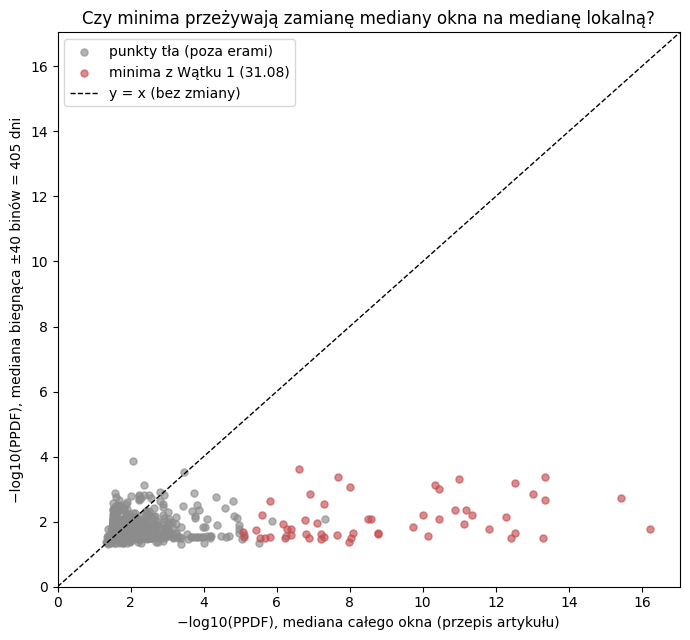

In [40]:
# Wykres 1 (jedno kodowanie: polozenie punktu): wynik w przepisie artykulu
# kontra wynik z mediana lokalna 365 dni, punkt po punkcie. Linia y=x to
# "nic sie nie zmienilo". Minima i tlo rysowane osobno, zeby bylo widac,
# czy mediana lokalna zjada wszystko po rowno, czy tylko minima.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6.5))
for rodzaj, kolor, etykieta in [("tlo", "#8C8C8C", "punkty tła (poza erami)"),
                                ("minimum", "#C44E52", "minima z Wątku 1 (31.08)")]:
    s = wyniki[wyniki["rodzaj"] == rodzaj]
    ax.scatter(s["neglog10_artykul"], s[f"neglog10_{WARIANT_GLOWNY}"],
               s=26, alpha=0.65, color=kolor, label=etykieta)

lim = [0, max(wyniki["neglog10_artykul"].max(),
              wyniki[f"neglog10_{WARIANT_GLOWNY}"].max()) * 1.05]
ax.plot(lim, lim, color="black", ls="--", lw=1, label="y = x (bez zmiany)")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("−log10(PPDF), mediana całego okna (przepis artykułu)")
ax.set_ylabel("−log10(PPDF), mediana biegnąca ±40 binów = 405 dni")
ax.set_title("Czy minima przeżywają zamianę mediany okna na medianę lokalną?")
ax.legend()
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/local_median_scatter.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/local_median_scatter.png")


Zapisano ../results/local_median_contrast.png


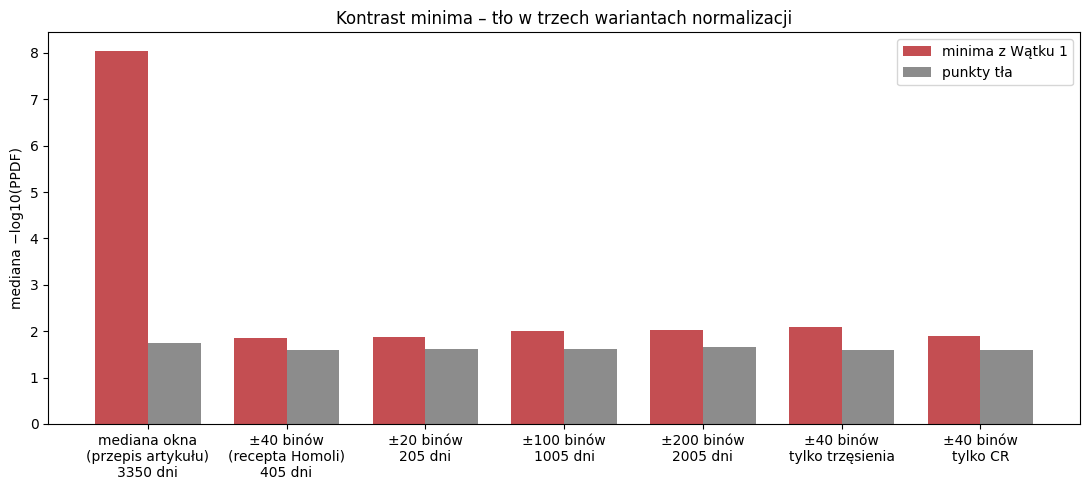

In [41]:
# Wykres 2 (jedno kodowanie: wysokosc slupka): mediana -log10 PPDF w
# minimach i w tle, wariant po wariancie. Pokazuje wprost, czy kontrast
# minima-tlo przezywa zmiane normalizacji.
warianty = [n for n, _, _ in WARIANTY]
etykiety = {
    "artykul": "mediana okna\n(przepis artykułu)\n3350 dni",
    "homola_n40": "±40 binów\n(recepta Homoli)\n405 dni",
    "waska_n20": "±20 binów\n205 dni",
    "szeroka_n100": "±100 binów\n1005 dni",
    "szeroka_n200": "±200 binów\n2005 dni",
    "tylko_EQ_n40": "±40 binów\ntylko trzęsienia",
    "tylko_CR_n40": "±40 binów\ntylko CR",
}
etykiety = [etykiety[n] for n in warianty]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(warianty))
w = 0.38
mins = [podsum[(podsum.wariant == v) & (podsum.rodzaj == "minimum")]["mediana_neglog10"].iloc[0]
        for v in warianty]
tla = [podsum[(podsum.wariant == v) & (podsum.rodzaj == "tlo")]["mediana_neglog10"].iloc[0]
       for v in warianty]
ax.bar(x - w / 2, mins, w, label="minima z Wątku 1", color="#C44E52")
ax.bar(x + w / 2, tla, w, label="punkty tła", color="#8C8C8C")
ax.set_xticks(x)
ax.set_xticklabels(etykiety)
ax.set_ylabel("mediana −log10(PPDF)")
ax.set_title("Kontrast minima – tło w trzech wariantach normalizacji")
ax.legend()
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/local_median_contrast.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/local_median_contrast.png")


Zapisano ../results/local_median_per_minimum.png


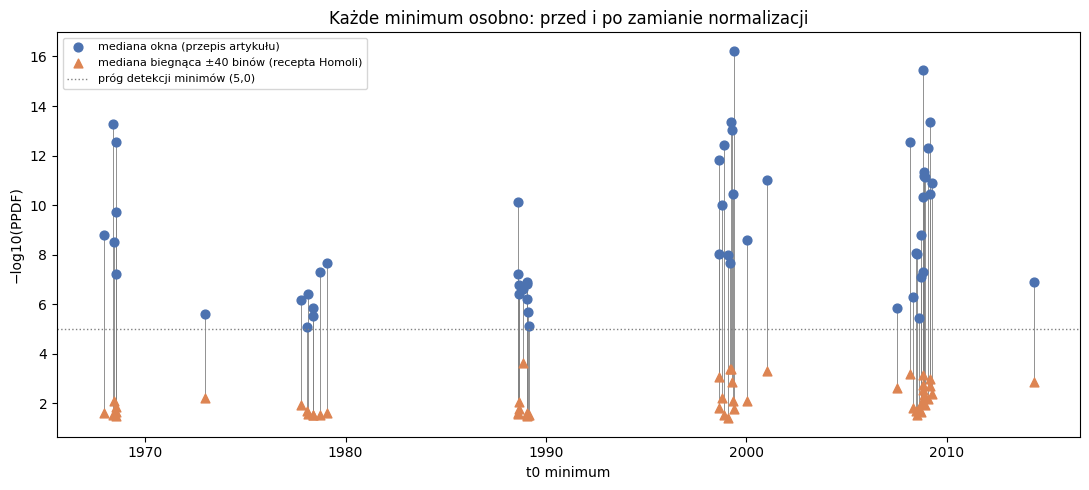

In [42]:
# Wykres 3 (jedno kodowanie: polozenie punktu na osi czasu): same minima,
# era po erze - czy mediana lokalna uderza rownomiernie we wszystkie ery,
# czy tylko w stare (co bylby argumentem, ze stare ery zyja z dlugofalowego
# trendu, a nie z lokalnego zwiazku CR-EQ).
fig, ax = plt.subplots(figsize=(11, 5))
mn = wyniki[wyniki["rodzaj"] == "minimum"].sort_values("t0")
ax.scatter(mn["t0"], mn["neglog10_artykul"], s=40, color="#4C72B0",
           label="mediana okna (przepis artykułu)")
ax.scatter(mn["t0"], mn[f"neglog10_{WARIANT_GLOWNY}"], s=40, marker="^", color="#DD8452",
           label="mediana biegnąca ±40 binów (recepta Homoli)")
for _, r in mn.iterrows():
    ax.plot([r["t0"], r["t0"]], [r["neglog10_artykul"], r[f"neglog10_{WARIANT_GLOWNY}"]],
            color="gray", lw=0.6, zorder=0)
ax.axhline(5.0, color="gray", ls=":", lw=1, label="próg detekcji minimów (5,0)")
ax.set_xlabel("t0 minimum")
ax.set_ylabel("−log10(PPDF)")
ax.set_title("Każde minimum osobno: przed i po zamianie normalizacji")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/local_median_per_minimum.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/local_median_per_minimum.png")


Okno diagnostyczne: hrms, t0=1999-05-18 12:00:00, -log10 PPDF (artykul) = 16.23
Zapisano ../results/local_median_mechanism.png

Liczba zmian znaku w tym oknie (dla ciagu losowego byloby ok. polowy
liczby wazacych binow, czyli rzedu 330):
  mediana okna (artykul)       A:  127, B:  247   (wazacych binow: 667)
  mediana biegnaca +-40 binow  A:  248, B:  293   (wazacych binow: 650)


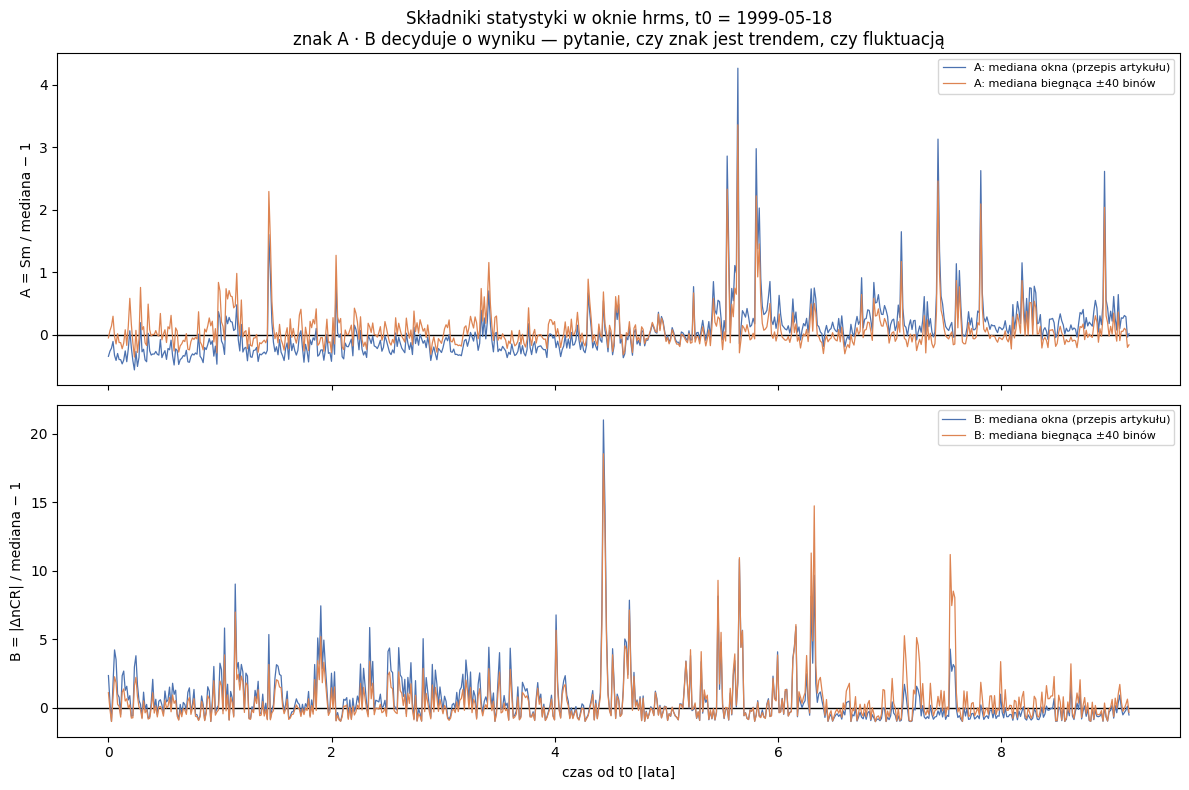

In [43]:
# Wykres 4 (dwa panele, w kazdym jedno kodowanie: wartosc w funkcji
# numeru binu) - DIAGNOSTYKA MECHANIZMU. Jesli kontrast minima-tlo znika po
# przejsciu na mediane lokalna, natychmiastowe pytanie brzmi "dlaczego" -
# i to jest komorka, ktora na nie odpowiada, zamiast zostawiac sama liczbe.
#
# Bierzemy NAJSILNIEJSZE policzone minimum i rysujemy w jego oknie oba
# skladniki statystyki: A (trzesienia) i B (zmiennosc CR), w wersji z
# mediana okna i z mediana kroczaca. Hipoteza artefaktu przewiduje
# konkretny obraz: w wersji artykulu A i B skladaja sie z kilku DLUGICH
# blokow jednego znaku (powolny trend przecinajacy mediane okna raz czy
# dwa), a nie z fluktuacji bin-po-binie. Dwa takie trendy sa ze soba
# zgodne juz z samego przebiegu w czasie i daja ogromny nadmiar N+ bez
# zadnego lokalnego zwiazku CR-EQ.
najlepsze = wyniki[wyniki["rodzaj"] == "minimum"].nlargest(1, "neglog10_artykul").iloc[0]
st_diag, t0_diag = najlepsze["station"], najlepsze["t0"]
print(f"Okno diagnostyczne: {st_diag}, t0={t0_diag}, "
      f"-log10 PPDF (artykul) = {najlepsze['neglog10_artykul']:.2f}")

bins_diag = binuj_okno(load_cr(st_diag), eq, t0_diag)
A_art, B_art = skladniki_A_B(bins_diag, None, None)
A_lok, B_lok = skladniki_A_B(bins_diag, 40, 40)
osx = np.arange(len(A_art)) * D_DAYS / 365.25

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.axhline(0, color="black", lw=1)
ax1.plot(osx, A_art, lw=0.9, color="#4C72B0", label="A: mediana okna (przepis artykułu)")
ax1.plot(osx, A_lok, lw=0.9, color="#DD8452", label="A: mediana biegnąca ±40 binów")
ax1.set_ylabel("A = Sm / mediana − 1")
ax1.set_title(f"Składniki statystyki w oknie {st_diag}, t0 = {t0_diag.date()}\n"
              "znak A · B decyduje o wyniku — pytanie, czy znak jest trendem, czy fluktuacją")
ax1.legend(fontsize=8)

ax2.axhline(0, color="black", lw=1)
ax2.plot(osx, B_art, lw=0.9, color="#4C72B0", label="B: mediana okna (przepis artykułu)")
ax2.plot(osx, B_lok, lw=0.9, color="#DD8452", label="B: mediana biegnąca ±40 binów")
ax2.set_ylabel("B = |ΔnCR| / mediana − 1")
ax2.set_xlabel("czas od t0 [lata]")
ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/local_median_mechanism.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/local_median_mechanism.png")
print()
print("Liczba zmian znaku w tym oknie (dla ciagu losowego byloby ok. polowy")
print("liczby wazacych binow, czyli rzedu 330):")
for etykieta, (A_, B_) in [("mediana okna (artykul)", (A_art, B_art)),
                            ("mediana biegnaca +-40 binow", (A_lok, B_lok))]:
    ok = np.isfinite(A_) & np.isfinite(B_) & (A_ != 0) & (B_ != 0)
    print(f"  {etykieta:28s} A: {liczba_zmian_znaku(A_[ok]):4d}, "
          f"B: {liczba_zmian_znaku(B_[ok]):4d}   (wazacych binow: {ok.sum()})")


In [44]:
# Podsumowanie watku, z jawnie wypisana regula czytania wyniku - ustalona
# ZANIM zobaczylismy liczby, zeby nie dopasowywac interpretacji do tego,
# co wyszlo (plan, Watek 4: "obie odpowiedzi sa warte dnia pracy").
print("=" * 70)
print("WATEK 4 (mediana lokalna) - PODSUMOWANIE")
print("=" * 70)
print()
print("Reguly czytania, ustalone z gory:")
print("  A. Kontrast minima-tlo utrzymuje sie we wszystkich wariantach  ->")
print("     wzorzec NIE jest artefaktem normalizacji oknem ~9-letnim, bo")
print("     przezywa nawet wtedy, gdy znak jest okreslany lokalnie. To")
print("     najmocniejszy argument, jaki dzis mozemy dostac.")
print("  B. Kontrast znika przy medianie biegnacej, a N_valid sie nie zmienia")
print("     ->  znak w wariancie artykulu byl sterowany zmiennoscia WOLNA,")
print("     dluzsza niz okno mediany biegnacej, a nie zgodnoscia bin-po-binie.")
print("     UWAGA - to NIE jest jeszcze dowod artefaktu. Ten sam wynik dalby")
print("     efekt fizycznie realny, ale wolny (a artykul twierdzi wlasnie, ze")
print("     efekt ma skale cyklu slonecznego!). Mediana biegnaca +-40 binow")
print("     usuwa z definicji wszystko, co zmienia sie wolniej niz ~2000 dni,")
print("     wiec kasuje zarowno trend-artefakt, jak i powolny sygnal.")
print("     Co wtedy odroznia jedno od drugiego: (1) drabina okien - przy")
print("     jakiej dlugosci okna kontrast ginie, (2) warianty jednostronne -")
print("     czy trend siedzi po stronie trzesien (wspolnej dla calej sieci,")
print("     patrz Watek 3) czy po stronie CR, (3) liczba zmian znaku.")
print("  C. Kontrast znika, ale N_valid tez wyraznie spada  ->  wynik")
print("     nierozstrzygniety: stracilismy statystyke, a nie sygnal.")
print("  Rozstrzygniecie miedzy B i C daje kolumna 'zmian znaku': jesli w")
print("  wariancie artykulu znak A i B zmienia sie duzo rzadziej niz co drugi")
print("  bin (ok. 330 przy ~665 binach), to znak jest sterowany trendem, a")
print("  nie fluktuacja - czyli scenariusz B, z widocznym mechanizmem.")
print()
for nazwa, _, _ in WARIANTY:
    m = wyniki[wyniki["rodzaj"] == "minimum"]
    t = wyniki[wyniki["rodzaj"] == "tlo"]
    print(f"{nazwa:15s}: mediana w minimach {m['neglog10_' + nazwa].median():6.2f}, "
          f"w tle {t['neglog10_' + nazwa].median():6.2f}, "
          f"kontrast {m['neglog10_' + nazwa].median() - t['neglog10_' + nazwa].median():+6.2f}, "
          f"mediana N_valid {m['N_valid_' + nazwa].median():5.0f} / "
          f"{t['N_valid_' + nazwa].median():5.0f}, "
          f"zmian znaku A {m['zmiany_A_' + nazwa].median():5.0f}, "
          f"B {m['zmiany_B_' + nazwa].median():5.0f}")
print()
print("Rozbicie po erach (mediana -log10 PPDF w minimach danej ery):")
tab = (wyniki[wyniki["rodzaj"] == "minimum"]
       .groupby("era")[[f"neglog10_{n}" for n, _, _ in WARIANTY]]
       .median().round(2))
print(tab.to_string())
print()
print("ZASTRZEZENIE do dziennika: mediana kroczaca to ODSTEPSTWO od przepisu")
print("artykulu. Raportujemy to jako test odpornosci naszego wyniku, nie jako")
print("poprawke metody artykulu ani nowa wersje replikacji.")


WATEK 4 (mediana lokalna) - PODSUMOWANIE

Reguly czytania, ustalone z gory:
  A. Kontrast minima-tlo utrzymuje sie we wszystkich wariantach  ->
     wzorzec NIE jest artefaktem normalizacji oknem ~9-letnim, bo
     przezywa nawet wtedy, gdy znak jest okreslany lokalnie. To
     najmocniejszy argument, jaki dzis mozemy dostac.
  B. Kontrast znika przy medianie biegnacej, a N_valid sie nie zmienia
     ->  znak w wariancie artykulu byl sterowany zmiennoscia WOLNA,
     dluzsza niz okno mediany biegnacej, a nie zgodnoscia bin-po-binie.
     UWAGA - to NIE jest jeszcze dowod artefaktu. Ten sam wynik dalby
     efekt fizycznie realny, ale wolny (a artykul twierdzi wlasnie, ze
     efekt ma skale cyklu slonecznego!). Mediana biegnaca +-40 binow
     usuwa z definicji wszystko, co zmienia sie wolniej niz ~2000 dni,
     wiec kasuje zarowno trend-artefakt, jak i powolny sygnal.
     Co wtedy odroznia jedno od drugiego: (1) drabina okien - przy
     jakiej dlugosci okna kontrast ginie, (2) wari